In [60]:
import kagglehub
import pandas as pd
import numpy as np
import datetime

traffic_df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")
df = pd.DataFrame(traffic_df)

y = traffic_df['traffic_volume']
X = traffic_df.drop('traffic_volume', axis=1)
df.head(10)

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00
5,5181,NaN,291.72,0.0,0.0,1,Clear,sky is clear,02-10-2012 14:00
6,5584,NaN,293.17,0.0,0.0,1,Clear,sky is clear,02-10-2012 15:00
7,6015,NaN,293.86,0.0,0.0,1,Clear,sky is clear,02-10-2012 16:00
8,5791,NaN,294.14,0.0,0.0,20,Clouds,few clouds,02-10-2012 17:00
9,4770,NaN,293.10,0.0,0.0,20,Clouds,few clouds,02-10-2012 18:00


# Dataset analysis and preparation
Since the data is not all numbers, it is required to convert the qualitative categories into quantitative lists.

In [53]:
df['holiday'].unique()

df['isHoliday'] = pd.notna(df['holiday'])
print(df['weather_main'].unique())
# Maybe needed to adapt the order to make sense to the description.
unique_weathers = df['weather_main'].values
df['weather_cat'] = pd.factorize(unique_weathers)[0]



df.head(10)

['Clouds' 'Clear' 'Rain' 'Drizzle' 'Mist' 'Haze' 'Fog' 'Thunderstorm'
 'Snow' 'Squall' 'Smoke']


,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,isHoliday,weather_cat
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00,False,0
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00,False,0
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00,False,0
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00,False,0
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00,False,0
5,5181,NaN,291.72,0.0,0.0,1,Clear,sky is clear,02-10-2012 14:00,False,1
6,5584,NaN,293.17,0.0,0.0,1,Clear,sky is clear,02-10-2012 15:00,False,1
7,6015,NaN,293.86,0.0,0.0,1,Clear,sky is clear,02-10-2012 16:00,False,1
8,5791,NaN,294.14,0.0,0.0,20,Clouds,few clouds,02-10-2012 17:00,False,0
9,4770,NaN,293.10,0.0,0.0,20,Clouds,few clouds,02-10-2012 18:00,False,0


First attempt with the dataset : use only quantitative data

In [67]:
Xp = traffic_df.drop('weather_main', axis=1)
Xp = Xp.drop('weather_description', axis=1)
Xp['isHoliday'] = pd.notna(Xp['holiday']).astype(int)
Xp = Xp.drop('holiday', axis=1)
yp = traffic_df['traffic_volume']; Xp = Xp.drop('traffic_volume', axis=1)
#datetime.time('02-10-2012 09:00')
Xp['date_time'] = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M')
Xp['hour'] = Xp['date_time'].dt.hour
Xp = Xp.drop('date_time', axis=1)

print(np.array(Xp))
Xp.describe()

[[288.28   0.     0.    40.     0.     9.  ]
 [289.36   0.     0.    75.     0.    10.  ]
 [289.58   0.     0.    90.     0.    11.  ]
 ...
 [282.73   0.     0.    90.     0.    21.  ]
 [282.09   0.     0.    90.     0.    22.  ]
 [282.12   0.     0.    90.     0.    23.  ]]


,temp,rain_1h,snow_1h,clouds_all,isHoliday,hour
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,0.001265,11.398162
std,13.338232,44.789133,0.008168,39.015750,0.035551,6.940238
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,0.000000,5.000000
50%,282.450000,0.000000,0.000000,64.000000,0.000000,11.000000
75%,291.806000,0.000000,0.000000,90.000000,0.000000,17.000000
max,310.070000,9831.300000,0.510000,100.000000,1.000000,23.000000


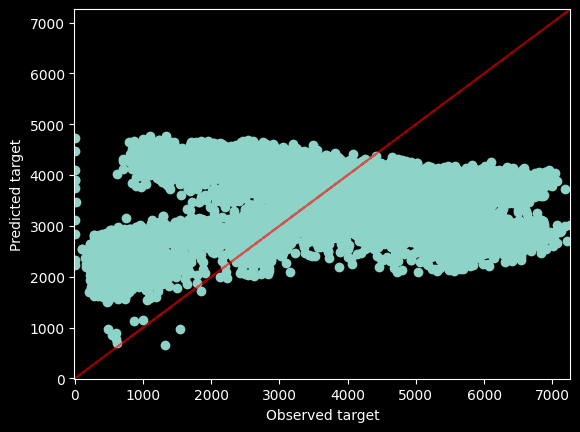

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(Xp, yp, test_size=0.2, random_state=1)
scalerX = StandardScaler()
X0_train = scalerX.fit_transform(X_train)

from sklearn.linear_model import LinearRegression

# Create the linear regression object
OLS_reg = LinearRegression().fit(X0_train, y_train)

# To test the regression, we need to scale and center also the test data
X0_test = scalerX.transform(X_test)
y_pred_OLS = OLS_reg.predict(X0_test)

plt.scatter(y_test, y_pred_OLS)
plt.plot(y_test, y_test, c='r', alpha=0.6, ls='--')
plt.xlim(y_test.min()-5, y_test.max()+5)
plt.ylim(y_test.min()-5, y_test.max()+5)
plt.xlabel('Observed target')
plt.ylabel('Predicted target')
plt.show()